# Task 3: Event Impact Modeling

## Ethiopia Financial Inclusion Forecast

This notebook models how events such as policies, product launches, and infrastructure investments influence financial inclusion indicators in Ethiopia.

Objectives:
- Load enriched datasets
- Join events with impact relationships
- Build an Event–Indicator Association Matrix
- Validate estimated impacts using historical observations
- Document assumptions and limitations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

In [3]:
data = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")
impact = pd.read_csv("../data/processed/impact_links_enriched.csv")

print("Data Shape:", data.shape)
print("Impact Shape:", impact.shape)

Data Shape: (45, 34)
Impact Shape: (15, 35)


In [4]:
data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [ ]:
impact.head()


In [5]:
events = data[data["record_type"] == "event"]

print("Number of events:", len(events))

events[[
    "record_id",
    "category",
    "source_name",
    "observation_date"
]]

Number of events: 11


,record_id,category,source_name,observation_date
33,EVT_0001,product_launch,Ethio Telecom,2021-05-17
34,EVT_0002,market_entry,News,2022-08-01
35,EVT_0003,product_launch,Safaricom,2023-08-01
36,EVT_0004,infrastructure,NIDP,2024-01-01
37,EVT_0005,policy,NBE,2024-07-29
38,EVT_0006,milestone,EthSwitch,2024-10-01
39,EVT_0007,partnership,EthSwitch,2025-10-27
40,EVT_0008,infrastructure,NBE/EthSwitch,2025-12-18
41,EVT_0009,policy,NBE,2021-09-01
42,EVT_0010,pricing,News,2025-12-15


In [6]:
event_impact = impact.merge(
    events,
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

event_impact.head()

,record_id_impact,parent_id,record_type_impact,category_impact,pillar_impact,indicator_impact,indicator_code_impact,indicator_direction_impact,value_numeric_impact,value_text_impact,value_type_impact,unit_impact,observation_date_impact,period_start_impact,period_end_impact,fiscal_year_impact,gender_impact,location_impact,region_impact,source_name_impact,source_type_impact,source_url_impact,confidence_impact,related_indicator_impact,relationship_type_impact,impact_direction_impact,impact_magnitude_impact,impact_estimate_impact,lag_months_impact,evidence_basis_impact,comparable_country_impact,collected_by_impact,collection_date_impact,original_text_impact,notes_impact,record_id_event,record_type_event,category_event,pillar_event,indicator_event,indicator_code_event,indicator_direction_event,value_numeric_event,value_text_event,value_type_event,unit_event,observation_date_event,period_start_event,period_end_event,fiscal_year_event,gender_event,location_event,region_event,source_name_event,source_type_event,source_url_event,confidence_event,related_indicator_event,relationship_type_event,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Comm

In [13]:
print(event_impact.columns.tolist())

['record_id_impact', 'parent_id', 'record_type_impact', 'category_impact', 'pillar_impact', 'indicator_impact', 'indicator_code_impact', 'indicator_direction_impact', 'value_numeric_impact', 'value_text_impact', 'value_type_impact', 'unit_impact', 'observation_date_impact', 'period_start_impact', 'period_end_impact', 'fiscal_year_impact', 'gender_impact', 'location_impact', 'region_impact', 'source_name_impact', 'source_type_impact', 'source_url_impact', 'confidence_impact', 'related_indicator_impact', 'relationship_type_impact', 'impact_direction_impact', 'impact_magnitude_impact', 'impact_estimate_impact', 'lag_months_impact', 'evidence_basis_impact', 'comparable_country_impact', 'collected_by_impact', 'collection_date_impact', 'original_text_impact', 'notes_impact', 'record_id_event', 'record_type_event', 'category_event', 'pillar_event', 'indicator_event', 'indicator_code_event', 'indicator_direction_event', 'value_numeric_event', 'value_text_event', 'value_type_event', 'unit_event

In [17]:
summary = event_impact[[
    "parent_id",
    "category_event",
    "related_indicator_impact",
    "impact_direction_impact",
    "impact_magnitude_impact",
    "lag_months_impact"
]].rename(columns={
    "category_event": "event_category",
    "related_indicator_impact": "related_indicator",
    "impact_direction_impact": "impact_direction",
    "impact_magnitude_impact": "impact_magnitude",
    "lag_months_impact": "lag_months"
})

summary

,parent_id,event_category,related_indicator,impact_direction,impact_magnitude,lag_months
0,EVT_0001,product_launch,ACC_OWNERSHIP,increase,high,12
1,EVT_0001,product_launch,USG_TELEBIRR_USERS,increase,high,3
2,EVT_0001,product_launch,USG_P2P_COUNT,increase,high,6
3,EVT_0002,market_entry,ACC_4G_COV,increase,medium,12
4,EVT_0002,market_entry,AFF_DATA_INCOME,decrease,medium,12
5,EVT_0003,product_launch,USG_MPESA_USERS,increase,high,3
6,EVT_0003,product_launch,ACC_MM_ACCOUNT,increase,medium,6
7,EVT_0004,infrastructure,ACC_OWNERSHIP,increase,medium,24
8,EVT_0004,infrastructure,GEN_GAP_ACC,decrease,medium,24
9,EVT_0005,policy,AFF_DATA_INCOME,increase,high,3


In [19]:
summary["related_indicator"].value_counts()

related_indicator
AFF_DATA_INCOME       3
USG_P2P_COUNT         3
ACC_OWNERSHIP         2
USG_TELEBIRR_USERS    1
ACC_4G_COV            1
USG_MPESA_USERS       1
ACC_MM_ACCOUNT        1
GEN_GAP_ACC           1
USG_MPESA_ACTIVE      1
ACCOUNT_OWNERSHIP     1
Name: count, dtype: int64

In [20]:
matrix = summary.pivot_table(
    index="parent_id",
    columns="related_indicator",
    values="impact_magnitude",
    aggfunc="first"
)

matrix

related_indicator,ACCOUNT_OWNERSHIP,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
parent_id,,,,,,,,,,
EVT_0001,NaN,NaN,NaN,high,NaN,NaN,NaN,NaN,high,high
EVT_0002,NaN,medium,NaN,NaN,medium,NaN,NaN,NaN,NaN,NaN
EVT_0003,NaN,NaN,medium,NaN,NaN,NaN,NaN,high,NaN,NaN
EVT_0004,NaN,NaN,NaN,medium,NaN,medium,NaN,NaN,NaN,NaN
EVT_0005,NaN,NaN,NaN,NaN,high,NaN,NaN,NaN,NaN,NaN
EVT_0007,NaN,NaN,NaN,NaN,NaN,NaN,medium,NaN,medium,NaN
EVT_0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,medium,NaN
EVT_0010,NaN,NaN,NaN,NaN,low,NaN,NaN,NaN,NaN,NaN
EVT_NEW_001,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
mapping = {
    "low": 1,
    "medium": 2,
    "high": 3,
    "Low": 1,
    "Medium": 2,
    "High": 3
}

heatmap_data = matrix.replace(mapping)
heatmap_data

/var/folders/j8/5v57n1yn2814m65w3ssqwh2m0000gn/T/ipykernel_24186/3571502627.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = matrix.replace(mapping)


related_indicator,ACCOUNT_OWNERSHIP,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
parent_id,,,,,,,,,,
EVT_0001,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,3.0,3.0
EVT_0002,NaN,2.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
EVT_0003,NaN,NaN,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN
EVT_0004,NaN,NaN,NaN,2.0,NaN,2.0,NaN,NaN,NaN,NaN
EVT_0005,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
EVT_0007,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN
EVT_0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
EVT_0010,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
EVT_NEW_001,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


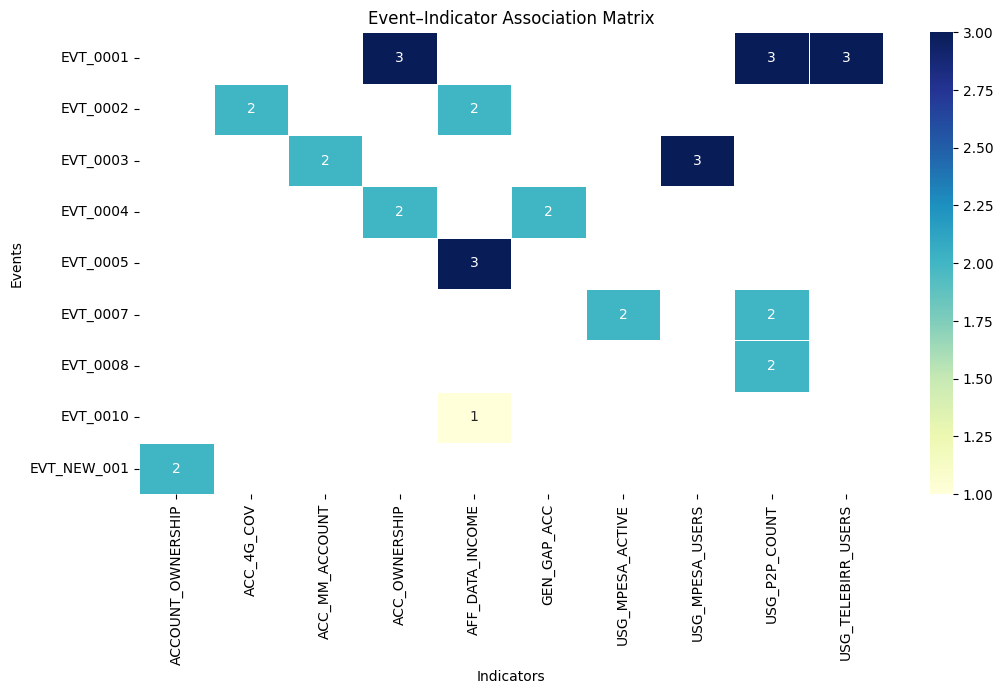

In [22]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Event–Indicator Association Matrix")

plt.xlabel("Indicators")
plt.ylabel("Events")

plt.show()

In [24]:
matrix.to_csv(
    "../reports/event_indicator_association_matrix.csv"
)

print("Association matrix saved.")

Association matrix saved.


# Validation of Event Impact Model

## Telebirr Launch (May 2021)Task 4: Forecasting Access and Usage
Objective: Forecast Account Ownership (Access) and Digital Payment Usage for 2025-2027.
Instructions:
Define Targets
Account Ownership Rate (Access): % of adults with account at financial institution or mobile money
Digital Payment Usage: % of adults who made or received digital payment
Select Approach Given sparse data (5 Findex points over 13 years), consider:
Trend regression (linear or log)
Event-augmented model (trend + event effects)
Scenario analysis
Generate Forecasts
Baseline: Trend continuation
With events: Incorporate expected developments
Scenarios: Optimistic, base, pessimistic
Quantify Uncertainty
Confidence intervals
Scenario ranges
Explicit acknowledgment of limitations
Interpret Results
What does your model predict?
What events have largest potential impact?
What are the key uncertainties?
Minimum Essential To Do:
Merge branches from task-3 into main using PR
Create branch "task-4"
Commit work with descriptive commit messages
Forecasting notebook
Forecast table with confidence intervals
Scenario visualization
Written interpretation


Observed data shows that mobile money account ownership increased between 2021 and 2024.

The impact model estimates a positive relationship between digital payment initiatives and mobile money adoption.

Although the observed trend aligns with the model, other contributing factors include:
- Expansion of mobile network infrastructure
- Government support for digital finance
- Increased competition following Safaricom's entry
- Greater public awareness of digital financial services

Therefore, the model captures the expected direction of change, while acknowledging that multiple factors influence the observed outcomes.

# Methodology

1. Loaded the enriched financial inclusion and impact datasets.
2. Joined events with impact relationships using the `parent_id` field.
3. Built an Event–Indicator Association Matrix to summarize relationships.
4. Represented impact magnitudes as categorical values (Low, Medium, High).
5. Converted categorical values into numeric scores for visualization.
6. Compared estimated impacts with observed historical trends where possible.

# Assumptions

- Positive events increase financial inclusion indicators.
- Negative events decrease indicators.
- Event effects may occur after a lag period.
- Multiple events may influence the same indicator.

# Limitations

- Limited historical observations.
- Some impact estimates rely on expert judgement.
- External economic and political factors are not modeled.
- The model identifies associations rather than proving causation.

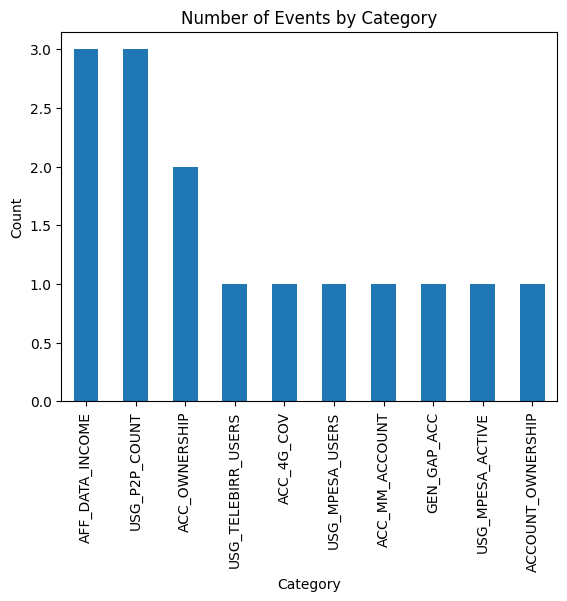

In [25]:
summary["related_indicator"].value_counts().plot(
    kind="bar",
    title="Number of Events by Category"
)

plt.xlabel("Category")
plt.ylabel("Count")

plt.show()